In [29]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

(1920, 1080)

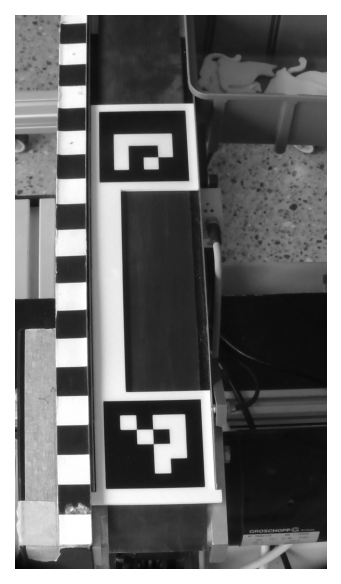

In [30]:
img = cv.imread("aruco_pic/aruco_0.png")
img = cv.rotate(img, 2)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

fig = plt.imshow(img_gray, cmap = 'gray', vmin=0, vmax=255)
plt.axis('off')
img_gray.shape

(1500, 545)

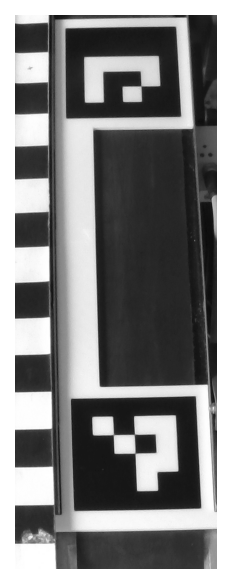

In [31]:
img_gray_focused = img_gray[300:1800, 155:700]

fig = plt.imshow(img_gray_focused, cmap = 'gray', vmin=0, vmax=256)
plt.axis('off')
img_gray_focused.shape

/tmp/ipykernel_23071/3416629946.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img_gray_focused.ravel(), 256, [0,256])


(array([3.0000e+00, 2.9000e+01, 1.8000e+01, 2.8000e+01, 2.9000e+01,
        2.7000e+01, 4.2000e+01, 1.3100e+02, 7.8000e+01, 1.1700e+02,
        1.2400e+02, 1.1600e+02, 1.7400e+02, 3.4600e+02, 6.1300e+02,
        2.2020e+03, 1.4060e+03, 8.9700e+02, 7.7300e+02, 9.8800e+02,
        1.4750e+03, 2.4930e+03, 6.1860e+03, 3.0023e+04, 1.4107e+04,
        9.8300e+03, 1.3429e+04, 1.4468e+04, 1.2829e+04, 1.1704e+04,
        1.0494e+04, 1.4018e+04, 8.9340e+03, 6.4480e+03, 7.7600e+03,
        9.0510e+03, 1.1740e+04, 1.5739e+04, 1.4020e+04, 2.2269e+04,
        3.6926e+04, 1.8358e+04, 1.8596e+04, 1.7218e+04, 1.4143e+04,
        9.9580e+03, 8.4290e+03, 1.1917e+04, 1.9322e+04, 9.3850e+03,
        8.4060e+03, 7.4720e+03, 5.6120e+03, 3.5090e+03, 5.6370e+03,
        5.3580e+03, 1.0451e+04, 4.3950e+03, 3.7680e+03, 2.6350e+03,
        1.9590e+03, 2.2370e+03, 2.3660e+03, 2.1960e+03, 3.7430e+03,
        1.5440e+03, 1.3000e+03, 9.8300e+02, 1.3530e+03, 2.4230e+03,
        1.3030e+03, 1.3380e+03, 1.1700e+03, 2.00

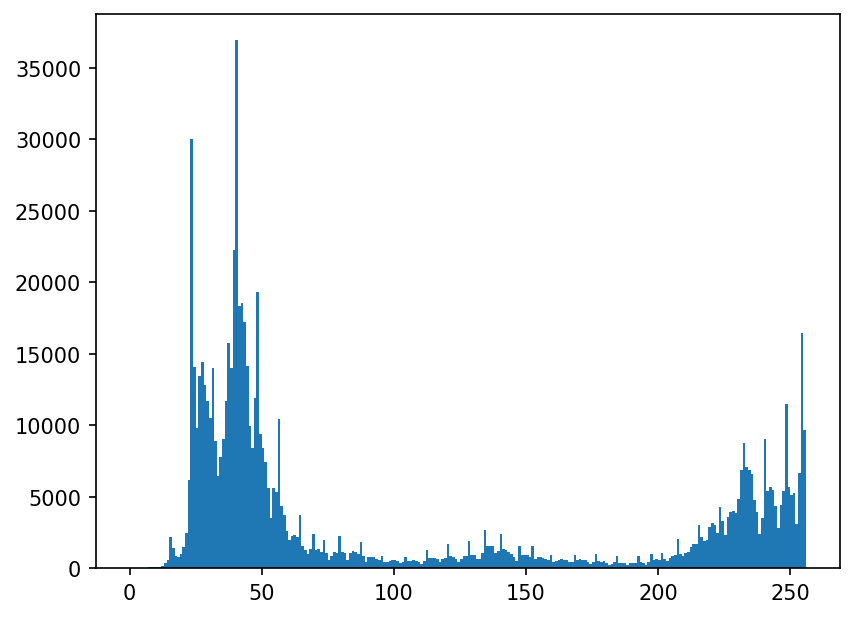

In [32]:
plt.hist(img_gray_focused.ravel(), 256, [0,256])

0.0 255.0


(np.float64(-0.5), np.float64(544.5), np.float64(1499.5), np.float64(-0.5))

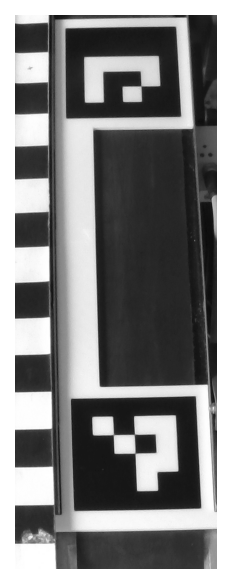

In [33]:
img_spreaded = (img_gray_focused - img_gray_focused.min()) * (255.0 / (img_gray_focused.max() - img_gray_focused.min()))
print(img_spreaded.min(), img_spreaded.max())

fig = plt.imshow(img_spreaded, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

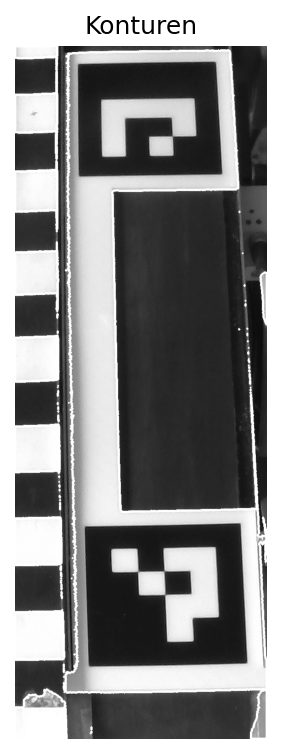

In [34]:
ret , img_thresh = cv.threshold(img_spreaded, 127, 255,cv.THRESH_BINARY)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = img_spreaded.copy()
cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')
plt.title('Konturen')
plt.axis('off')
plt.show()

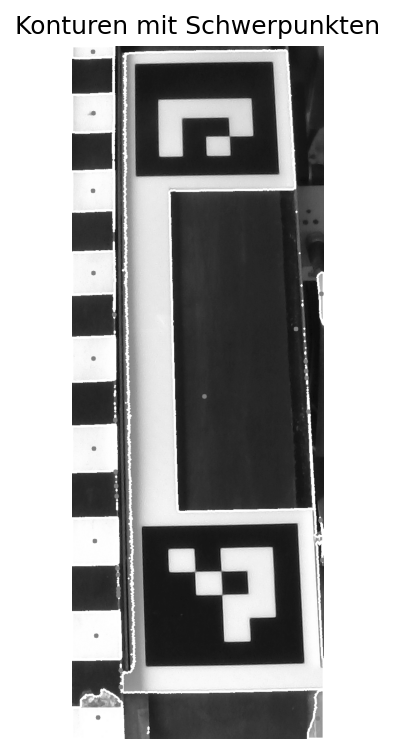

In [35]:
img_with_centroids = img_with_contours.copy()

for contour in contours:
    M = cv.moments(contour)
    
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        
        cv.circle(img_with_centroids, (cx, cy), radius=5, color=(128), thickness=-1)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_centroids, cmap='gray')
plt.title('Konturen mit Schwerpunkten')
plt.axis('off')
plt.show()

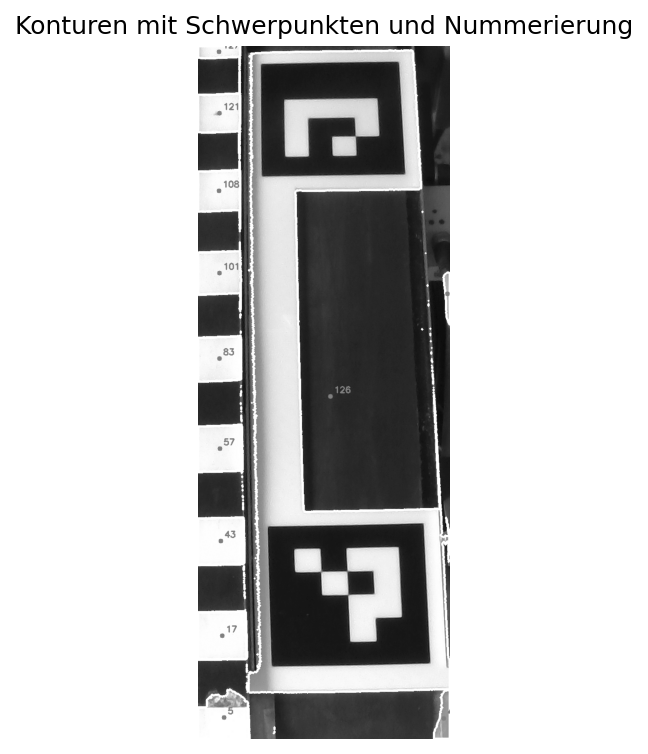

In [36]:
img_with_centroids = img_with_contours.copy()

for i, contour in enumerate(contours):
    if cv.contourArea(contour) < 100:
        continue
    
    M = cv.moments(contour)
    
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        
        cv.circle(img_with_centroids, (cx, cy), radius=5, color=(128), thickness=-1)
        
        cv.putText(
            img_with_centroids,
            text=str(i + 1),
            org=(cx + 8, cy - 8),
            fontFace=cv.FONT_HERSHEY_SIMPLEX,
            fontScale=0.6,
            color=(128),
            thickness=2,
            lineType=cv.LINE_AA
        )

plt.figure(figsize=(8, 6))
plt.imshow(img_with_centroids, cmap='gray')
plt.title('Konturen mit Schwerpunkten und Nummerierung')
plt.axis('off')
plt.show()